# 如何排查 GRPO 训练问题
- https://zhuanlan.zhihu.com/c_1419455237367623680

本系列文章会分享 GRPO 排查的经验。以及我作为面试官，考查 post-training 方向候选人时，<font color='red'>是如何判断对方是否有对应的能力</font>。

我不喜欢问固定的八股文，或者为难候选人手撕代码。而是更倾向于从具体案例中提问题，比如<font color='red'>让候选人分享一个训练出问题的案例，然后逐渐 dive deep，判断他有多少经历是编造的</font>，例如：

  - <font color='red'>遇到的是策略坍塌，还是训练崩溃？当时看到的情况是什么，查到了什哪些东西？</font>

**这类问题有意思的地方是每个人切入的角度都不太一样。**
- 有人从曲线角度入手，先分析哪几条指标先动了；
- 有的人先看数据，提到其实是样本有问题；
- 还有的从算法机制本身着手，**直接讲 GRPO 的目标函数天生往哪个方向偏**。

不论是哪个角度，经历过的人，最后通常都会聊到类似的内容。
- <font color='red'>比如提到组内 reward 没有方差、两侧算出来的概率对不上、或者某个指标看着正常但其实没有意义。</font>
- 审视的角度和方式不同，落点却都大差不差，可以说是殊途同归。

反过来，纯背八股，抄别人项目经历的人也比较类似，都喜欢说自己用 DAPO 或者 XXPO 里某个优化解决了某个问题，<font color='red'>但是回答不了各种追问：</font>
- 这个具体问题是怎么发现的？
- 在哪条曲线上看到征兆的？
- 当时怎么决定改哪个？
- 改完之后又遇到了什么新问题？

这个差距是无法在知识量上弥补的，没有经验，遇到类似问题也很难解决。

所以，这个系列我会按照自己遇到问题的时候，排查的顺序逐步展开，从我自己的角度分享，训练出问题时怎么修，逐步深入。

<font color='red'>这一篇我先分享最开始的一层：问题分类</font>

这个系列**主要讨论模型本身的排查**，不会涉及到reward model 或者 LLM judge 的排查，如果大家感兴趣，我未来也可以出一个相关的系列。


## 排查问题的基础要求
不管是从哪个角度开始排查，我们真正要关心的有三件事。

1. 先分类再动手。

  - <font color='red'>**策略坍塌**和**训练崩溃**是两类完全不同的问题。</font>
     - 这两类问题的解决方式差异很大，不可以混为一谈。

2. 要有observability 的意识。

  - 你有没有监控，监控了什么？
      - 更关键的是：<font color='blue'>你改了某个配置让指标动了，但你怎么知道是这个配置起了作用，还是恰好这批数据不一样？</font>

3. 如何分析每个方案的代价。

  - 直接叠上各种 PO 试图解决问题，并不是专业的做法。<font color='red'>每个 trick 都有它自己的适用前提，叠在一起用，连是哪个在起作用都分不出来。</font>

## 问题分类
在训练出问题的时候，我会区分问题到底是下面的哪一类：



In [1]:
from IPython.display import Image

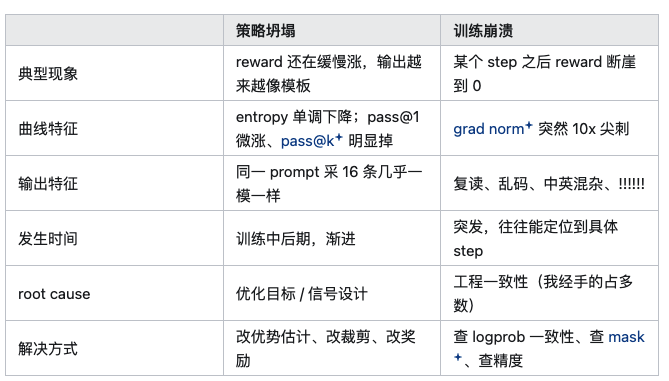

In [2]:
Image(filename='./Image/q_classification.png')

两者的解决方式差异很大。
- **策略坍塌**主要是算法层的问题，
  - 它是 GRPO 这个目标函数本身的内在倾向——你什么都没做错，它也会往那个方向走。

- **训练崩溃**通常都是在工程层：
  - 训练侧和采样侧算出来的概率不一致、loss mask 的覆盖范围写错了、bf16 精度不够导致数值失真。<font color='red'>这类问题调超参永远调不好，因为它压根不是超参问题，而是 bug</font>

## 进一步区分
现实世界是复杂的，这个二分法只是粗略的总结，不够严谨。所以不要只看这个表格来定位问题，下面我来解释原因。

### 问题的相互转化
<font color='red'>同一个现象，背后可能有多种原因在同时起作用</font>。一个比较常见的链路是这样的：

In [ ]:
熵先一路掉到底
   ↓
每个位置只剩一个答案
   ↓
输出开始退化成复读
   ↓
reward 断崖式暴跌

我们在最后一步看到的结果，很可能归因于训练崩溃，但病根其实在第一步策略坍塌。

反过来说，**坍塌的成因里往往还混着 reward 设计、一批数据被反复用了多轮，这些也都不是纯算法的问题。**

所以我们要做的不是确定这是策略坍塌还是训练崩溃。而是例如：
- 先按训练崩溃去查工程，因为工程层的问题要么有要么没有，等排除干净之后才轮到策略坍塌类。(详细解释见：排查顺序)

<font color='red'>从这个角度，如果你能在面试中，主动指出这两类会互相转化，会是一个很大的加分项。</font>



### 时间尺度 vs root cause
有一个理解起来比较绕的事情：从时间尺度上看，模型坍塌是渐进式的，而训练崩溃是突发式的。而从 root cause 角度，模式坍塌的 优化目标 / 信号设计，和训练崩溃的工程一致性，跟渐进式还是突发式并不是一一对应。这个理解起来有点绕，我可以举个例子：

・有效样本数退化是渐进的（几十步的过程），但病根其实在工程和系统层（异步、数据陈旧）。所以，虽然符合策略坍塌的渐进 + 中后期特征，但并不是要去查优化目标，而是工程层。 ・多轮工具调用崩溃，属于训练崩溃，但通常表现为突发的 grad norm 爆炸，但病根其实在信号设计（工具返回的内容把分布带偏，逐轮复合），而不是 mask 或者精度问题。

一个进阶的切法是用下面四问，按照信号链来区分：

1. 梯度是不是和我认为的 match？ 两侧 logprob 一致性、loss mask 覆盖范围、梯度累积等价性。
2. reward 是不是在测我认为它在测的东西？ 分项拆解、验证器的 false negative、和训练不同源的 held-out。
3. 这一步的更新是几条样本在决定？ 有效样本数、零方差组占比。
4. 策略还在看题吗？ 组内去重、跨输入的可区分度、pass@k。

这个方式区分，可以确保每一层之间是前提关系，而不是并列关系。 第 1 层不通过，后面三层的所有观测都没有意义；第 2 层不通过，第 3、4 层是在精确地优化一个错的东西。

这个切分方式，可以理解二分法给不出的依赖结构，因为渐进和突发之间没有前提关系。

我的二分法在多数情况下适用，但一些复杂情况，可以按照我讲的这个方式来分类。

## 最常见的错误排查方式
缺少经验的候选人，回答问题时，比较常用一类的回答，例如：“训练崩溃之后，把 lr 从 xxx 降到 yyy 就好了。”

降 lr 肯定有效，因为它把所有事情都拖慢了，包括 bug 本身。原来几百个 step 就爆的，现在几千个 step 才爆。如果你的训练本来只跑几千个 step，那你可能会以为问题解决了。这不是修好了，而是把爆炸推迟到了你的视野之外。

这个方法不是没用，把降 lr 当成诊断手段是完全没问题的。可以用它去区分到底是信任域太大，还是代码里有 bug，这是个合理的二分实验，信任域问题会随 lr 线性缓解，bug 不会。但是不能把它解决问题的最终解释。

类似的回答还有：加大 grad clip 的力度、把 warmup 拉长、把 batch size 翻倍。它们都能让曲线看起来变好，因为它们都在降低单步的实际更新量。判断标准很简单：如果你的修复手段是「让每一个 step 走得更小」，那你大概率没有定位到根因，只是把它稀释了。

## 我怎么快速判断
前面讲了为什么要分类，快速分类的方法，其实很简单：抓崩溃前后各 10～20 条 rollout，人工一条条读一遍。这一步第一步。

可以在 rollout 原文轻松发现是不是这三类问题：

- reward hacking：输出结构完整、格式漂亮，但内容在绕开真正的任务。比如该解题的地方在复述题干、该给答案的地方给了个模板化的推理过程。
- 大量截断：回答在句子中间断掉，JSON 没闭合，推理写到一半没了。
- 乱码 / 复读：!!!!!!、同一个短语重复几十遍、中英混杂到读不通。
而这三类在 reward 曲线上可能都只表现为掉到 0。从曲线上看，不如直接看原文。

## 总结
先分类，再动手。 坍塌和崩溃的排查路径完全不同，混着查等于两边都查不干净。顺序是固定的：先排工程层，因为它是 0/1 的；排干净了再动算法层。

分类法本身也要能被质疑。 我这个二分是按时间尺度切的，它有用但不严谨。按信号链切（梯度对不对 → reward 在测什么 → 几条样本在决定 → 还看不看题）更严格，因为这四层之间是前提关系。

降 lr 是诊断，不是解释。 更一般地说：任何「让每一步走得更小」的手段，都只是在稀释根因。

读原文在读曲线之前。 三分钟的人工阅读能完成的分类，曲线上要花半小时，而且还可能分错。

# GRPO如何监控模型的多样性？

本系列文章会分享 GRPO 排查的经验。以及我作为面试官，考查 post-training 方向候选人时，是如何判断对方是否有对应的能力。

上一篇文章中，我讲了策略坍塌和训练崩溃是两类不同的问题，为什么要先分类再动手，以及如何分类。这篇讲怎么发现问题，具体要监控什么。

网上的文章，在分享 GRPO 优化时，通常会分析上 clip-higher 的作用，或者加 dynamic sampling 的价值。但更值得问的是前一步：作者当时看到了什么，才决定用这个的？

GRPO 是没有 critic 的，唯一的学习信号来自同一个 prompt 采出来的一组回答间的相对优势。也就是说，信号本身的健康度是可以直接观测的，所以也必须观测。 如果一组里所有回答的 reward 都一样，那这一组压根没有信号，而这件事完全可以在曲线上看见，不需要猜。

监控指标我分两组讲。这篇专注讲解多样性这一组，也就是模型还会几种解法、还在不在探索。后面会讨论另一组信号健康度与一致性。

这一组有个共同的陷阱：它们看起来在测同一件事，其实漏掉了一整个维度。 这个我也会在后面的文章中详细展开。

## token entropy：模型还有多少不确定性
每生成一个 token 时，模型对整个词表输出一个概率分布，这个分布的熵就是该位置的 token entropy，可以对熵取平均。

它的含义：熵高说明模型在这个位置还在犹豫，好几个候选词概率都不低；熵低说明它已经很确定了。

正常什么样：训练过程中它应该缓慢下降。这是正常的，模型本来就是在变得更确定。

危险信号：下降速度很快，并且一路趋近 0。这时候模型对每个位置都只有一个答案，采 16 条会得到 16 条一样的东西，探索彻底停止。

但这个指标并没有大家理解的那么有价值。

  - 第一，取过平均的 token entropy 稳住了其实什么都证明不了。具体原因会在下面第四节展开来讲。

  - 第二，熵下降本身并不是问题。任何一次有效的 RL 都会让熵下降，这就是策略在锐化，是它该做的事。所以拿“熵在降”当坍塌的证据是不可证伪的，因为它同时也描述了健康的训练。我真正看的是下降的速率，以及同期 pass@k 有没有跟着掉。

  - 第三，更 tricky 的是，它掉到接近 0 也不能直接确诊坍塌。熵低但模型对不同题还给不同的推理，是在压缩，不是坍塌，模型可能反而非常稳定。而最坏的情况下，对所有题写类似的话术，熵反而是高的。具体的我会在第五节讲透。

所以我把 token entropy 放在第一个讲，只是因为它好观测、每个 step 都有。但是 token entropy 顶多算个粗糙的报警器，不是判据。

顺便回答一个常见问题：熵是不是越高越好？ 不是。熵过高的时候模型答案不稳定、难收敛，甚至连正确的输出格式都保不住。要维持的是一个目标区间，而不是一个方向。

## 组内去重率：16 个答案里实际有几个不一样
GRPO 对每个 prompt 采一组回答，把这一组做个去重，看还剩几条，就是组内去重率。

为什么要看它：这是熵坍塌最直观的表现。平均熵是把成千上万个 token 位置糊在一起的数字，很不敏感；而 16 条采样去重后只剩 2 条，是一眼就能看懂的。

危险信号：去重后的条数持续下降。降到 2 到 3 条基本就是坍塌了，因为 GRPO 的梯度来自组内比较，组内都一样了，就没有任何可比的东西。

严格的去重可以换成编辑距离的分布。完全字符相同的情况其实不多，更常见的是「结构一模一样、只有几个数字不同」。看编辑距离的中位数比看去重条数更灵敏一点。

## pass@k：能力上限有没有变窄
对同一道题采 k 条回答，只要其中有任意一条做对就算通过。pass@1 是采一条就对的比例，pass@k 是采 k 条里至少一条对的比例。

为什么这个指标最关键：pass@1 衡量的是模型最擅长的那条路走得多准，而 pass@k 衡量的是模型总共还会几种解法。RL 很容易把前者提上去、同时把后者压下去，因为它做的事情是把已有的某一条路径的概率推高，代价是别的路径被压没了。

危险信号：pass@1 在涨，但 pass@k 在跌，尤其是跌到低于 base model。这说明这一轮 RL 没有教给模型新东西，只是把它变窄了。

把 base model 和 RL 之后的模型放在同一张图上，随着 k 变大，两条线会交叉：

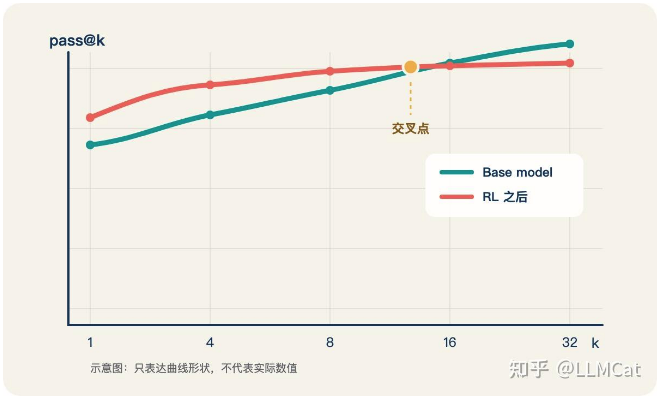

In [3]:
Image(filename='./Image/base_rl.png')

两条线都是往上走的，因为 k 越大、采样越多，命中的机会只会增加不会减少。区别在形状：RL 之后那条很快就见顶了，因为它只会一条路，采再多也是同一条；base model 那条会一直往上爬，因为它还留着好几种解法，多采就有机会撞到。

所以左半边 RL 明显更好，这就是 pass@1 上看到的提升；但两条线会在某处交叉，k 再大一点 base model 反而更高。

交叉点具体在哪取决于任务和模型，上图只是示意形状，不是可以照抄的数值。

### 如何取 k 取多少
我的做法是 k 就取 group size，最简单。

GRPO 训练时每个 prompt 本来就要采一组，我这边是 16 条，那 pass@16 直接从这批 rollout 里算出来就行，不额外花一分钱算力，每个 step 都有。这是我最常看的一条曲线。

评测集上我会另外跑一次，采到 32 条封顶。我没做过更多的，因为收益不明显，而成本是线性涨的。很多论文里的 k 采到几百上千，是为了把曲线画完整，日常调模型没必要，也没那个预算。当然，代价是只能看见比较严重的坍塌。

我最近见过一次反超在 pass@16 上。这一轮的坍塌比较严重，组内 16 条去重只剩 2 条，pass@1 涨了几个点，但 pass@16 比 base model 低，交叉点落在 8 到 16 之间。所以不用等到大 k，坍塌够狠的时候小 k 就能看出来。

但反过来的推论不成立：在 pass@16 上看不出差别，不代表没问题，只代表没严重到这个预算能看见的程度。

### 曲线的 3 个 gap
在看曲线时，要注意下面3点： ・训练 prompt 不是评测集。 rollout 是在训练 prompt 上的，它们正在被训练，pass@16 天然被污染、通常会偏高。 ・每个 step 的题不一样。 每个 step 的 batch 是不同的题，逐 step 之间的波动很大一部分是题目难度组成的抖动，不是策略变化。这条曲线跨 step 不可直接比，除非固定一个 probe 集。 ・如果开了零方差组过滤，这个数被系统性压低了。 过滤会把全对的组剔掉，于是算 pass@16 的那个子集里正确率天然更低，而且随着训练推进（全对组占比上升）持续下漂。你会看到一条自己造出来的、像坍塌的下降曲线。要算就在过滤之前算。

我的做法：rollout 上的曲线，只当同 batch 内的相对信号看趋势；如果真的要和 base 比，需要另外固定一个几十道题的 probe 集，每隔一段时间两个模型各按自己调好的 temperature 跑一次。

### temperature 也要考虑在内
base 和 rl 两个模型的最优 temperature 不一样，但哪一边更高没有普适规律。

有些测量显示 base 的表现在 temperature 超过 1.0 之后就开始掉，而 RL 之后的模型对 temperature 反而不敏感。机制上也支持这个方向，RL 把分布锐化了、熵更低，要恢复同等有效熵得给 RL 那边加 temperature，而 base 本来就散。

我还遇到过完全反过来的情况，我没法给出原因：一开始拿训练时的 temperature （0.8）同时评两个模型，看着 RL 后完胜；后来给 base 单独调到 1.0，差距立刻缩小了一截。

所以我没法把它总结成规律，只能总结成一条经验：

只对比 pass@k ，不扫 temperature等于没比；而且两边必须各自扫一遍temperature、各取自己的最优点再比。
只要用训练时那个temperature同时评两个模型，这个比较就天然偏向 RL，因为那个temperature是 RL 训出来的工作点。

## 只在高不确定性位置统计的熵
第一节提到过，平均熵很弱，这一节展开讲讲为什么，以及一个部分的补救。

平均 token entropy 是个被稀释得很厉害的指标。 一条长回答里，绝大多数 token 是语法、连接词、格式符号，这些位置的熵天然就不低、而且基本不变。

真正决定解题路径的其实是少数几个分叉 token：选哪种方法、要不要回头验算、用哪个公式。这几个关键 token 完全确定化了，对平均熵的影响可能都不到 1%，但序列级的多样性已经死了。

所以一个直接的改法是：只统计那些 top-1 概率低于某个阈值的位置的熵，绕开被格式 token 稀释的问题。

这个指标也有个问题：它的条件集会随着策略锐化而不断收缩。策略越确定，符合「高不确定性」条件的位置就越少，极端情况下集合变空、数值就没意义了。所以它跨 step 不能直接比较。

我的解决办法有三个：

1. 用一个固定的位置集，比如拿一个冻结的参考模型一次性选定，之后一直用这批位置。
2. 把集合大小和数值一起报，看到集合在缩就知道数值不可比了。
3. 用分位数而不是绝对阈值（比如每个 batch 取熵最高的 20% 位置），这样集合大小恒定。这个第三种最简单，很多框架也内置了这个选项。

## 五、跨输入的可区分度
这一节最重要，因为前面四个指标都只看了“同一道题”，没有看“换一道题”。“答案不重复”和“答案贴合题目”不是一回事。题内多样性指的是，同一道题采样N次，有多种解法。而跨题可区分度，指的是换一道题，推理是否也跟着换。这一章节，会从这个角度展开。

先想两个模型：

- 模型 A：同一道题采 16 次，答案几乎一样；但题目一换，它会立刻换公式、换推理路径。这个模型可能只是变得更确定、更简洁，不一定坍塌。
- 模型 B：同一道题采 16 次，每次措辞都不一样，看起来很有多样性；但无论问数学、代码还是逻辑题，它都用同一套开场、自我检查和收尾。这个模型看似热闹，实际上已经模板化了。

前四节的平均熵、组内去重、pass@k 和条件熵，主要能区分“同一道题多采几次，答案像不像”。它们不擅长区分模型 A 和模型 B，因为缺了另一个问题：换一道题，推理会不会跟着换？

### 先把两个维度分开
可以把它们理解成两根互不替代的指标：

题内多样性：固定一道题，重复采样时能得到多少种不同答案。
跨题可区分度：换成不同题目后，模型的推理内容是否也明显不同。

用信息论记号写，题内多样性是 H(Z | X)；跨题可区分度对应 I(X:Z)。如果不熟悉这两个公式，可以先跳过。真正要记住的只有一句：
  - “同一道题的答案不重复”，不等于“答案真的根据题目而变化”。
  
它们之间满足：
H(Z) = I(X;Z) + H(Z | X)

这条公式想说的是：我们看到的总体变化，既可能来自同一道题有多种解法，也可能来自不同题目触发了不同推理。只盯着前一部分，就会漏掉“所有题都套同一模板”的坍塌。

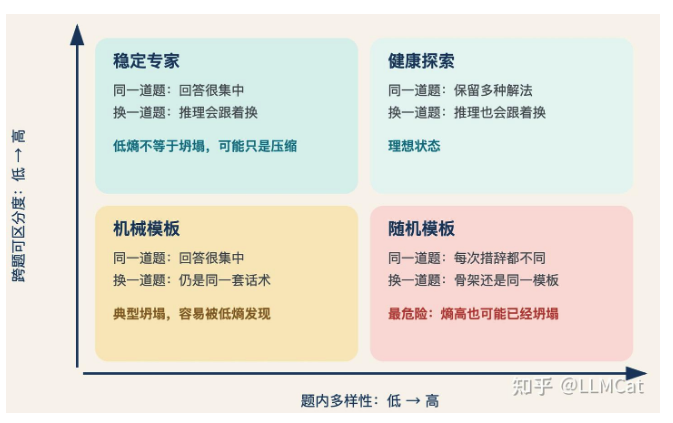

In [4]:
Image(filename='./Image/entropy_reason.png')

这里最反直觉的是右下角：模型每次都换几个词，所以熵不低、去重率也正常；但它对所有题都沿用同一个推理骨架。这是高熵也会坍塌的原因。

反过来，左上角虽然熵低、同一道题的回答也很集中，但每道题仍然会触发对应的推理。它更像是在压缩表达，而不是失去能力。

### 怎么测：让回答“找回自己的题目”
这个指标可以用一个很直观的小测试来算。

假设一个 batch 里有 P 道题，每道题都已经生成了回答。对其中一条回答，分别计算：

  - 它放回自己的题目后面时，模型给出的 logprob；
  - 它放到另外 P-1 道题后面时，模型给出的 logprob。
如果模型真的根据题目组织推理，那么“回答 A + 题目 A”的匹配分数应该最高。把每条回答都这样测一遍，统计它能否找回自己的题目，就是这里的检索准确率。

  - 准确率高：不同题目的推理确实有区别，输入依赖还在。
  - 准确率接近 1/P：和随机猜题差不多，说明回答已经很难看出是为哪道题写的，模板化很严重。
这项检查可以复用训练时已经生成的 rollout，不需要再采样；主要成本是补一次前向计算。

### 为什么零方差组会让模板化更严重
当一组回答的 reward 都一样时，任务本身几乎不给模型“这道题应该怎么改”的方向。可 KL、entropy bonus 等正则项仍然会产生更新，而且这些更新更像一种对所有输入都通用的推力。

于是这一 step 里，模型收到的主要不是“题目 A 应该这样答、题目 B 应该那样答”，而是“不管什么题，都统一往这个方向调一点”。如果零方差组很多，这种输入无关的更新会反复累积，不同题目之间原有的差异就会被慢慢抹平。

这也解释了第一节的反常现象：

- 熵低，但检索准确率高：模型更确定了，不过仍然会看题下菜，通常是健康压缩。
- 熵高，但检索准确率接近随机：模型的用词很多变，却对所有题套同一个骨架，这是更隐蔽的模板坍塌。
所以平均熵不只是“不能单独报平安”，它有时连报警方向都可能相反。必须把题内多样性和跨题可区分度放在一起看。

顺便说一句，这一节的内容在面试里我很少直接问。但如果候选人讲完监控之后，自己提到“同一题内的多样性和跨题的可区分度不是一回事”，那基本可以确认他真的自己搭过看板。

## 总结
平均熵是成本最低也最弱的指标。 它稳住了什么都证明不了，掉到 0 也不能直接确诊，熵下降本身还是健康训练的正常表现。它只值得作为一条随手看的报警线。

pass@k 的 k 取 group size，因为它免费。 但要清楚那条免费曲线的四处缺口：base 侧要额外跑、训练 prompt 有污染、跨 step 不可比、开了零方差过滤会被系统性压低。

报 pass@k 必须报temperature，而且两边各自调优后再比。 用训练temperature同时评两个模型，这个比较是偏的。

「同一题内多样性」和「跨题可区分度」是两个能反向走的量。 只测前者的看板，测不到「输出像模板」这个最典型的坍塌现象。补它只需要一次前向。

下一篇讲另一组指标：零方差组占比、重要性比与 clip fraction、两侧引擎的 logprob 差、长度与 grad norm、以及有效样本数。

# GRPO问题排查：怎么监控训练信号的健康度

本文为系列文章的第三篇，这个系列会分享 GRPO 排查的经验。以及我作为面试官，考查 post-training 方向候选人时，是如何判断对方是否有对应的能力。

在 GRPO 出现问题的时候，可以查看两组指标，上一篇讲了「多样性」那一组指标，熵、组内去重、pass@k、跨输入可区分度。这篇讲另一组：信号本身健不健康、两侧算的东西一不一致。

这一组的共同点是它们更工程、更容易被指标名字骗。

先给一张阅读地图。这篇其实只回答五个问题：

- 这一批 rollout 里，有多少组根本没提供学习信号？
- 模型更新后，离生成这些数据时的旧策略有多远？
- 采样引擎和训练框架算出来的概率是不是同一回事？
- 长度、梯度和总 reward 的异常，分别该怎么拆？
- 表面上有几百条样本时，真正决定梯度的到底有几条？

前四个问题是在找故障，最后一个问题是在找故障出现前的预警。

## 零方差 group 占比：这个 batch 里有多少组是白跑的
一个 group 就是同一个 prompt 采出来的那一组回答。如果这一组里所有回答拿到的 reward 完全一样（全对，或者全错），那这一组叫零方差 group。

### 错误观点：「超过 50% 的报警线」
这是网上流传很广的一个阈值，但它不靠谱，因为零方差组占比会随着 group size 
 自动变化。

给定题集的解题率分布，占比的期望是

$E_x[p^G + 「1 - p]^G$

假设某类题单条回答有 50% 的概率做对。只采 4 条时，四条刚好全对或全错并不稀奇；采到 32 条时，32 条恰好全对或全错就极难发生。

题目没变，只是 
 变了，零方差组的自然占比就会大幅变化。所以 50% 这条线在小 group size 下容易一直报警，在大 group size 下又可能一直沉默。

正确的判据是实测占比对比题集难度分布预测出来的基线：把上面那个期望算出来当基准，实测显著超出才叫异常。



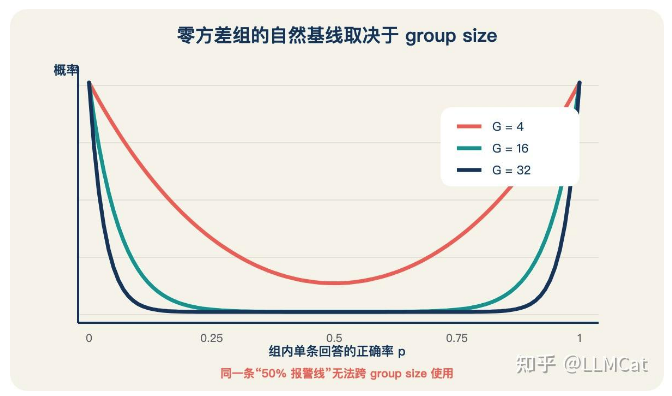

In [5]:
Image(filename='./Image/group_size.png')

如果实测和预测吻合呢？那说明问题不在训练动力学上，而在题集难度分布上，该换数据，不是该开过滤。

顺带：这个指标有的框架已经内置了，叫 frac_reward_zero_std，不用自己写。

### 危害深入分析
主流实现（例如DAPO 那种 token 级归一化）会把整个 batch 的 loss 加起来，再除以 batch 里的 token 总数。

可以把它想成“总贡献 ÷ 总人数”。零 advantage token 对总贡献是 0，却仍然算在总人数里。假设一个 batch 有 1000 个 token，其中 500 个来自零方差组：分子只收到另外 500 个 token 的贡献，分母却仍然除以 1000。

所以损失的不只是半个 batch，有效梯度也被整体稀释了。效果上很像同时减小了 batch size 和学习率。

要注意，这个压低的系数是零 advantage token 的占比，不是 group 的占比。而全对的组通常回答偏短、全错的组通常偏长（甚至撞截断），所以这两个数一般不相等。要估准就得量 token level 的比例。

还有一层：如果开了 KL loss 或者 entropy bonus，这些组并不是完全没梯度，而是只剩下一个把模型往参考策略拉回去的正则项，一点 reward 信号都没有。这比单纯的无效更糟，它在用你的算力做纯粹的回退。而且那个方向是与输入无关的，会持续抹平不同题之间的差异。

## 重要性比与 clip fraction
GRPO 会先采一批数据，再拿这批数据更新模型。问题是：做到第二个、第三个更新 step 时，模型已经变了，手里的回答却还是旧模型生成的。

ratio 就是在量“现在的模型”和“生成这条数据时的模型”差了多少。 对每个 token：

$ratio = \frac{π_θ(token)}{π_{old}(token)}$


也就是更新后的模型给这个 token 的概率，除以采样时的模型给它的概率。

ratio 可以直接当成概率的涨跌倍数：ratio = 1 表示没变，1.05 表示涨了 5%，0.8 表示降了 20%。健康训练里，大多数 token 的 ratio 应该接近 1。

clip 在做什么：PPO 和 GRPO 把 ratio 强行限制在 $[1 - \epsilon,1 + \epsilon]$ 里（典型 $\epsilon = 0.2$），超出的部分梯度不再生效，防止一个 step 走太远。clip fraction 就是有多少比例的 token 撞到了这个边界。

危险信号有两个。

  - 一是 clip fraction 突然涨到 20% 以上，说明更新步子普遍太大，或者数据已经太旧了。

  - 二是 ratio 出现极端离群值，比如某几个 token 的 ratio 是 $e^5$这种量级。均值会把这种情况完全藏住，所以要看分位数和最大值。

把上界和下界合成一个 clip fraction，就像只报“今天一共进出 100 万”，却不告诉你是流入还是流出。总量一样，方向可能完全相反。

一个典型的坍塌前兆是：上界几乎不命中、下界大量命中。也就是许多 token 的概率在往下掉，很少有 token 能往上探索。两个方向一合并，这个结构就消失了。

这个是我个人总结出来的，在多数框架上不是通用的，是要自己写代码。

这两个计数在所有框架的实现里都是按 advantage 符号门控的，而且结构上必然如此：PPO 的 min决定了上界只在 $\hat{A} > 0$时可能命中、下界只在 $\hat{A} < 0$ 时可能命中。

所以这两个计数不能脱离 advantage 来读。上界计数只会看见正 advantage 的 token，下界计数只会看见负 advantage 的 token。

“下界命中很多”可能是策略真的在大面积压概率，也可能只是这个 batch 里负 advantage 本来就更多。看上下界时，必须把正负 advantage 的数量一起分析。

## 两侧引擎的 logprob 差：最容易被忽略，也最致命
现在的 RL 训练基本都是两套东西配合：用推理引擎（vLLM / SGLang）快速生成回答，用训练框架（FSDP / Megatron）算梯度。

问题在于，同一条序列、同一份权重，这两套东西算出来的 token 概率并不完全一样。kernel、batch 组织和量化方式不同，都会带来差异。

它很像两把刻度略有偏差的尺子：一把量“旧概率”，另一把量“新概率”。你把两个读数一除，以为看到的是模型变化，其实里面还混着尺子本身的误差。

为什么这个非常严重：如果直接拿推理引擎返回的 logprob 当上面说的 $π_{old}$，那么 ratio 的分子分母来自两个不同的实现。这时候即使模型参数一个字都没变，ratio 也不等于 1，而算法会把这个偏差误读成策略已经漂移了很远，然后据此调整梯度。

具体怎么量：把同一批 token 分别送进两套引擎，计算每个 token 的 $|\delta logp|$，然后至少看三个数：均值、高分位数和最大值。

为什么不能只看均值？假设一万个 token 里：
  - 9990 个 token 的差异都在 0.001 左右；
  - 另外 10 个 token 的差异却非常大。
  
最后算出来的均值仍然可能很小，看上去一切正常；但那 10 个异常 token 仍有可能撞到 clip 边界，甚至产生异常梯度。所以这里需要把“整体是否一致”和“有没有少数危险 token”分开检查。

三个统计量可以这样分工：

  - mean：看整体误差是否普遍变大。我的经验是，均值低于 0.001 通常算健康；接近或超过 0.01 时应该停下来检查。最好先用一套确认正常的配置跑出自己的 baseline。
  - p99 / p99.9：看最异常的 1% 或 0.1% token 是否越来越多、越来越严重。它比单独看 max 稳定。
  - max：只回答“这一批里最极端的单个 token 差了多少”，适合定位具体异常样本。
  
要特别注意：上面的 0.01 是给 mean 用的，不是给 max 用的。即使训练健康，一大批 token 里也可能偶尔出现一个差异很大的极端值。如果要求 max < 0.01，几乎每个 batch 都可能报警，这条规则就失去意义了。

所以判断是否需要停训，主要看 mean；判断少数异常 token 有没有变多，则看 p99、p99.9 和 max 的变化趋势。

## 长度、grad norm、reward 分项
### 长度爆涨别直接判 hack
看均值、p99，加上截断率。

长度单调爆涨的时候，先把长度按对错拆开，分别画：

E[|o| | 答对] 和E[|o| | 答错 ]

  - 两条一起涨、而且答对那条涨得更快 → 这才是长度 hack，去查 reward 里哪个分项和篇幅正相关。
  - 只有答错那条在涨 → 这不是 hack，这是 $1/|o_i|$那项长度归一化的机械后果：错误样本的负 advantage 被长度摊薄了，于是写长一点能少罚一点。
  
这个区分非常要紧，因为两种情况的解决方式是相反的。前者改 reward；后者必须改 loss 聚合（token-level loss，或者干掉  $1/|o_i|$，这种情况才会需要用到 DAPO 中的小trick）。

这时候去加长度惩罚是错的方向，而且不只是无效：给错误答案加连续长度惩罚，在组归一化下容易产生发散的 advantage，结构上就容易把 reward 训崩。

「单调爆涨就是长度 hack」这个说法把现象和机制搞混了。爆涨只说明长度这个维度上有压力失衡，压力从哪来得靠拆开才知道。

其余两条：

  - 塌缩到几十个 token 是反过来了，模型学到的教训是「别说长话」，通常是截断样本的处理方式出了问题。
  - 截断率飙升要警惕，那意味着大量样本在撞 max_len，这些样本的 reward 通常是废的。
### grad norm 要看裁剪前的
主流框架默认记的基本都是裁剪前的，裁剪函数的返回值本来就是缩放前那个 norm。所以在 wandb 上看到 grad_norm: 8.3 而配置里 max_grad_norm=1.0，不是bug，而是说明这一步的梯度被整体缩小了 8.3 倍。

自己写的时候要注意，先 log 再剪裁，否则从曲线上看不到尖刺到底有多大。危险信号是突然出现 10 倍以上的尖刺。

### reward 必须按分项拆开
总 reward 是最容易骗人的指标。格式分、长度分能单独把它顶上去，而你真正在意的正确性分项可能一动不动。

只看总分，会把「学会了排版」当成「学会了解题」。

不过要注意别把训练早期误判成 hacking：刚开训的时候模型是先学格式、后学正确性的，所以「格式分涨、正确性平」是一个正常形状。真正要看的是这个状态持续了多久，以及正确性分项有没有在到达 plateau 之后开始下滑。

## ESS：batch 里有多少样本真正起了作用
batch size 只表示这一批放进了多少样本，并不保证每条样本对梯度的影响差不多。

假设一个 batch 有 512 条回答。如果它们的重要性权重比较接近，梯度确实综合了几百条样本的信息。但如果少数几条的权重特别大，其余样本几乎可以忽略，那么这个 step 名义上用了 512 条，实际却主要由那几条高权重样本决定。

ESS（Effective Sample Size，有效样本数）就是用来量这件事的：

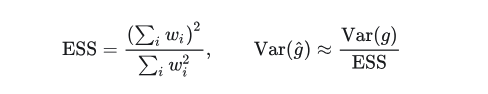

In [6]:
Image(filename='./Image/ess.png')

这里的 $w_i$是重要性权重。这个公式不用死记，抓住两种情况就够了：

  - 权重分得比较均匀，ESS 会接近真实的 batch size；
  - 权重集中在少数样本上，ESS 会明显低于 batch size。
例如，batch size 是 512，ESS 只有 8，不是说只剩 8 条样本有非零梯度，而是说：从梯度估计的稳定性来看，这一步大致只相当于用了 8 条权重均匀的样本。 其他样本并非完全没用，只是少数高权重样本占据了过大的影响。

实际监控时，我更常看 ESS / batch_size，也就是 ESS ratio。这样换了 batch size，曲线仍然可以比较。

### 为什么它比 grad norm 更早
训练失稳通常有一个积累过程：先是重要性权重越来越集中，接着 KL 和 grad norm 开始异常，最后才反映到 reward 上。



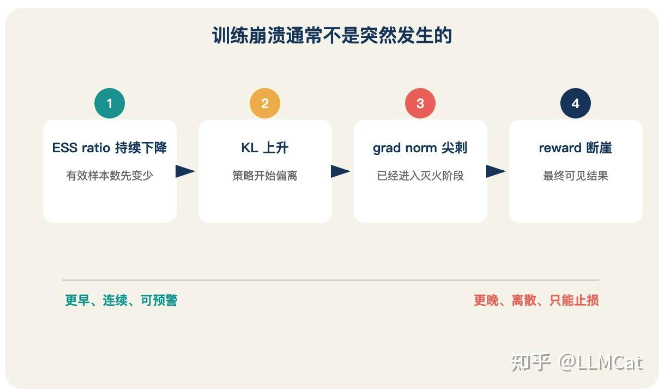

In [7]:
Image(filename='./Image/ess_step.png')

ESS ratio 的优势在于它会逐步下降，因此往往能在 grad norm 出现尖刺之前给出信号。grad norm 尖刺更像一次明确的异常事件；看到它时，训练通常已经进入需要止损和定位问题的阶段。

这里不需要把图里的先后顺序理解成每次都严格成立。更准确的说法是：ESS 观察的是风险如何集中，grad norm 观察的是这种集中是否已经产生了剧烈更新。 前者更适合预警，后者更适合确认训练已经不稳。

### ESS 下降后，先判断是哪一种偏差
ratio 变得不均匀，不一定都是因为 rollout 太旧。至少要区分两种情况：

  - 策略陈旧：生成回答后，模型又更新了多次。当前策略和生成数据时的旧策略确实已经拉开距离。
  - 两侧引擎不一致：模型权重没有变化，只是采样引擎和训练框架算出的 logprob 不同。
前者是真实的策略移动，可以从更新次数、异步延迟或 ppo_epochs 入手；后者是工程和数值一致性问题，应该回到第三节检查两侧 logprob。

两种偏差最终都会进入 ratio，也都会拖低 ESS。如果只看一条合并后的 ratio 或 ESS 曲线，很容易把引擎误差当成“数据太旧”，然后错误地去调 ppo_epochs。

面试时我偶尔会追问 ESS，不是想听公式，而是看候选人能不能说明两件事：它为什么比 batch size 更接近“真正参与梯度的样本数”，以及 ESS 下降后如何区分策略陈旧和引擎不一致。

## 总结
这篇不太适合背固定阈值，更实用的是按一条顺序去看训练信号。

先看 group 里有没有可比较的 reward。零方差组没有任务梯度，但它的正常占比取决于 group size 和题目难度，不能统一用 50% 判断。

再看 ratio 本身是否可信。采样引擎和训练框架可能给出不同的 logprob，因此同一份权重下 ratio 也可能偏离 1。判断整体一致性看 mean；检查少数异常 token，则看 p99、p99.9 和 max。

然后看 梯度是否开始被少数样本控制。ESS 比 batch size 更能反映这一步用了多少有效信息。ESS ratio 持续下降，通常比 grad norm 尖刺更早；但解释它之前，必须先排除两侧引擎不一致。

最后再看 长度、grad norm 和 reward 分项。这些指标更接近已经表现出来的结果：长度要按对错拆，grad norm 要看裁剪前，总 reward 要拆成正确性、格式、长度等奖励分项。

整套监控想回答的其实是同一个问题：这一批数据提供了多少可信的比较信号，这些信号有没有被少数样本或工程误差带偏，最后又以什么形式反映到模型更新上。

# GRPO策略坍塌的根因与去掉 std 归一化的代价

本系列文章会分享 GRPO 排查的经验。以及我作为面试官，考查 post-training 方向候选人时，是如何判断对方是否有对应的能力。

本系列前面的文章已经讲过怎么区别策略坍塌和训练崩溃。这篇从“为什么会塌”开始。

先回顾一个典型现象：训练到中后期，同一道题采 16 条回答，去重后只剩两三种；训练 reward 仍在上涨，pass@1 也可能变好，但测试集开始掉点，pass@16 甚至低于 base model。

这不是简单的“模型什么都不会了”。它更像是模型把赌注全压在少数几条路径上：最常出现的答案越来越稳定，其他原本也能解题的路径却逐渐采不到了。

为什么 GRPO 会把模型推向这个状态？要先看清一次训练更新是怎么产生的：

1. 对同一个 prompt 采一组回答；
2. 给每条回答打 reward；
3. 在组内计算谁高于平均、谁低于平均，得到 advantage；
4. 用 advantage 调整这些回答中 token 的概率；
5. 更新后的模型再去生成下一批回答。

如果组内比较可靠，这个循环会让好答案更常出现。如果某条回答只是偶然胜出，却在第三步被赋予过大的 advantage，它下一轮就会更常出现；出现得越多，又越容易继续被强化。策略坍塌就是这样逐轮积累出来的。

这篇只追其中一个问题：一组回答已经打完分以后，这些分数是怎么变成更新权重的？

GRPO 通常会把每条回答的 reward 减去组内均值，再除以组内标准差 
。这个操作看起来只是把数字整理到相近的尺度，却会改变“哪条回答对这一步更新最有影响”。下面先把它放回完整训练链路，再用一组具体分数把计算拆开。

## 先确定问题发生在哪一步
先把五类 root cause 放回刚才那条训练流程里。它们不是五个并列的技巧，而是在不同环节破坏了不同东西。



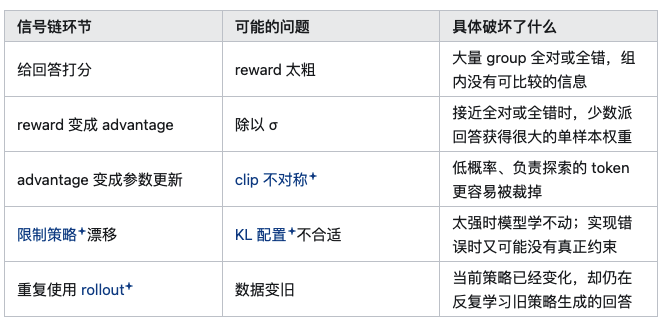

In [8]:
Image(filename='./Image/steps.png')

这张表也说明了为什么不能看到坍塌就直接“上 clip-higher”。如果 reward 本身让大多数 group 都没有方差，问题发生在 clip 之前；如果 ratio 里混入了陈旧数据，单改 $\sigma$ 也解决不了。

本文主要处理第二行：reward 已经有高低之分，但这些分数经过组内标准化以后，更新权重是否还符合我们对信号可靠性的判断。  $\sigma$归一化不是策略坍塌的唯一原因，也不是看到坍塌就该关闭的开关；这里只分析它具体改变了什么。

标准 GRPO 的 advantage 是：

$\hat{A_i} = \frac{r_i - \mu}{\sigma}$

这里的 advantage 可以先理解成一条回答在这一步训练中的“有符号权重”：

- 正数表示提高这条回答中 token 的概率，负数表示压低；
- 绝对值越大，这条回答对本次更新的影响通常越大；
-  $r_i - \mu$决定方向和原始分差，除以$\sigma$ 则把这组分差重新换了一个尺度。

减均值负责回答“谁比同组平均更好”，除以 $\sigma$负责回答“这组差异整体按多大音量进入训练”。问题在于， $\sigma$ 只知道分数有多分散，并不知道这些分差究竟代表可靠能力，还是偶然采样和 reward 噪声。

## 从一组具体分数看 σ 到底改变了什么
先从最简单的二值 reward 开始：答对得 1 分，答错得 0 分。假设一道题采 10 条回答，其中 9 条正确、1 条错误；实际训练用 8、16 或其他 group size，关系是一样的。

### 第一步只减均值。组内平均分是 0.9，所以：

  - 每条正确回答的分差是 1 - 0.9 = +0.1
  - 唯一错误回答的分差是 0 - 0.9 = -0.9
  
  这一步已经让少数派的单样本权重更大了。因为 9 条正确回答各自只比平均值高一点，而唯一的错误回答离平均值很远。正负分差加起来仍然是 0。

### 第二步才是除以 $\sigma$。这组 0 和 1 的标准差是 0.3，于是所有分差统一乘以 ：
  - 正确回答从 +0.1变成约 +0.33
  - 错误回答从 -0.9变成 -3
因此，除以 $\sigma$不是只挑出少数派单独放大，而是把整组分差统一放大；少数派原本离均值最远，所以最后拿到最大的绝对权重。

把中等题、简单题和难题放在一起看，结果如下：

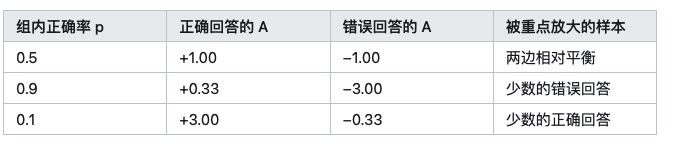

In [9]:
Image(filename='./Image/compare.png')

表里的数字按总体标准差计算，方便观察关系。框架如果采用无偏标准差，数值会略小，但形状不变。

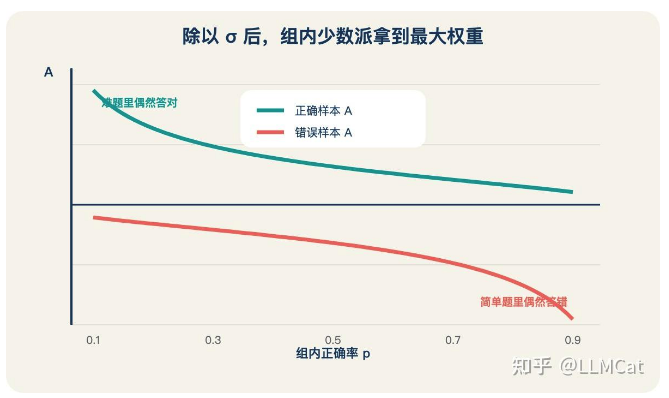

In [10]:
Image(filename='./Image/sigma.png')

这里最值得警惕的不是“少数派一定是错的”，而是：单样本权重主要由它在组内有多稀少决定，而不是由我们对它有多确信决定。

在难题里，唯一答对的回答可能是一次真正有价值的探索，也可能只是碰巧猜中；在简单题里，唯一答错的回答可能暴露了稳定缺陷，也可能只是一次采样失误。 $\sigma$ 归一化无法区分这些情况，它只会按组内分数的位置分配权重。

### 从刚才的例子怎么得到通用公式

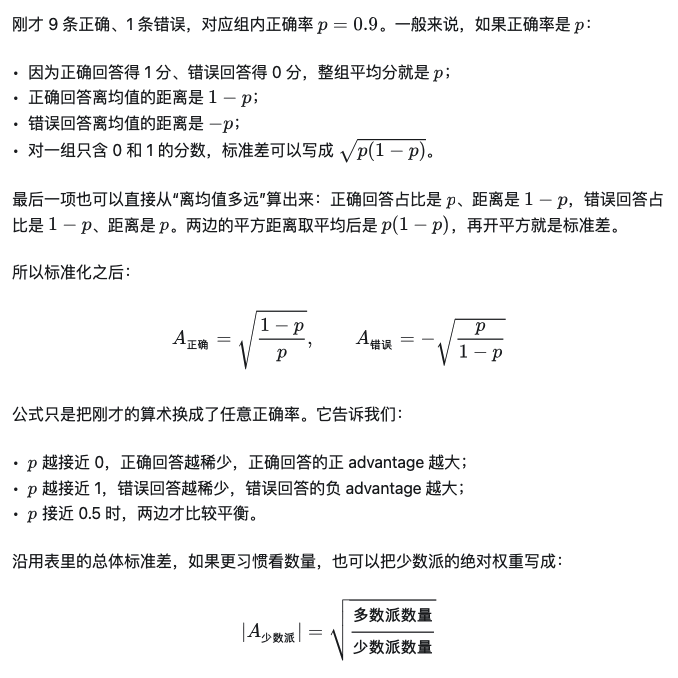

In [11]:
Image(filename='./Image/2.1.png')

这不是两次独立的放大，而是同一次标准化的两个观察角度：

  - 从题与题之间看，接近全对或全错的 group， $\sigma$更小，原始分差会被换算到更大的尺度；
  - 从一道题内部看，少数派离均值最远，因此它的单样本绝对权重最大。
最终风险取决于这些少数派样本是否可靠。如果 reward 准确、唯一正确答案确实展示了可复用的方法，大权重可能有帮助；如果 reward 有噪声，它也会把偶然胜出的样本推得很重。

### 为什么曲线看似趋于无穷，实际却有上限


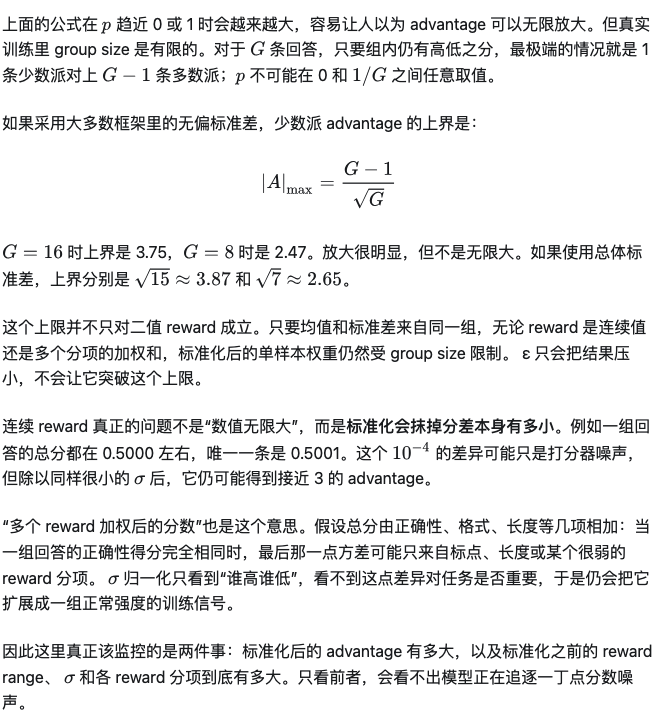

In [12]:
Image(filename='./Image/2.2.png')

## 去掉 σ的本质

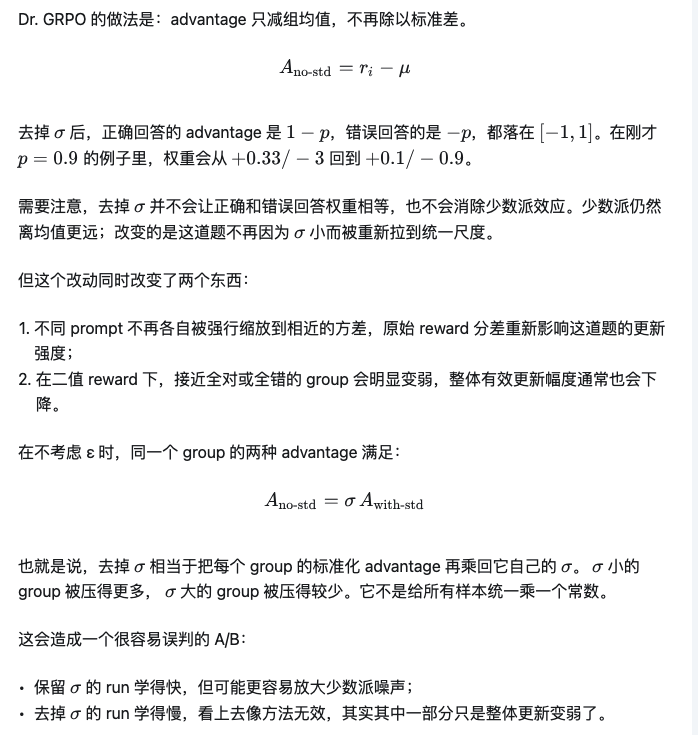

In [13]:
Image(filename='./Image/3.png')

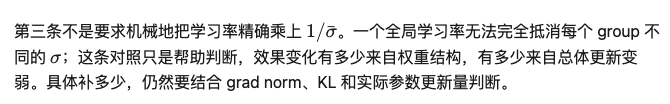

In [14]:
Image(filename='./Image/3.0.png')

### σ 归一化的价值
 $\sigma$归一化并非毫无价值。它在做一种逐 prompt 的自适应缩放：不管原始 reward 分差是 0.001 还是 1，都尽量把它们换算到相近的尺度。这样不同 prompt 更容易提供接近强度的训练信号。

问题在于，reward 方差小可能有两种完全不同的含义：

  - 分差虽小，但排序可靠，确实值得学习；
  - 分差小是因为大家几乎一样，剩下的差别主要是 reward 噪声或次要分项。
$\sigma$归一化无法区分两者。去掉它会降低第二类噪声的影响，但也会让“差距小却可靠”的偏好信号变弱。所以这是 trade-off，不是一次没有代价的 bug 修复。

###  σ 和长度归一化的区别
Dr. GRPO 中，还删除了回答长度归一化项 $1/|o_i|$。这两项对应的是不同偏置：

  - **除以$\sigma$ **：改变不同难度题目和组内少数派的权重，属于 difficulty bias。
  - 除以回答长度：让长回答的单位 token 惩罚更轻，尤其会减弱长错误回答的负 advantage，属于 length bias。
  
论文把长度失控归因于 $1/|o_i|$，而不是$\sigma$ 。由于两项是一起删除的，论文没有提供两者对长度影响的独立消融。遇到错误回答越来越长时，应该先检查 loss 是否按回答长度做了归一化。

## 过滤零方差组的目的
当一组 16 条回答全对或全错时，$r_i - \mu$来就是 0。无论是否除以 $\sigma$，advantage 都是 0。

这意味着：去掉 $\sigma$只能处理“仍有方差，但正确率很极端”的 group，处理不了严格的全对或全错。

DAPO 的 dynamic sampling 走的是另一条路：丢掉零方差 group，继续采样，直到凑够指定数量的有效 group。这样训练 batch 里每个 group 都至少包含两种 reward。

这个方法提高了训练数据的利用率，但不是没有成本的。

### 第一项代价：生成开销取决于数据难度
如果零方差组很少，重采样成本可以被生成—训练流水线隐藏；如果六七成 group 都是全对或全错，为了凑满有效 batch 就要生成大量额外回答。

所以不要直接照搬论文里的时间开销结论。需要同时记录：零方差组比例、为了补齐 batch 实际生成了多少 group，以及生成能否与训练并行。

### 第二项代价：训练目标的权重变了
零方差 group 本来就没有任务梯度，所以问题不在“删掉了什么信号”，而在“删掉以后又用什么补进来”。

例如，普通采样一次得到 10 个 group，其中可能只有 4 个有高低分；这一步真正提供任务梯度的就只有 4 个。动态采样会继续生成，直到凑满 10 个有高低分的 group。于是每个 optimizer step 看到的有效比较更多，更新通常也更强。

同时，不同 prompt 被保留下来的概率并不相同。中等难度的题更容易同时采到对和错，会更频繁地进入最终 batch；几乎全对或全错的题需要反复重采样，甚至一直进不来。训练数据因此被重新加权了。

至于零梯度 token 是否仍占 loss 的归一化分母，要看具体框架的 reduce 方式。这个实现细节会影响动态采样把更新放大多少，但不改变上面的核心事实：最终参与每一步训练的 prompt 分布已经变了。

### 第三项代价：已经掌握的能力更容易被看不见
一个常见说法是：“全对的题被过滤，所以模型在这些题上没有梯度，最后遗忘了。”这条因果不准确，因为全对 group 在原始 GRPO 里 advantage 也是 0，本来就没有任务梯度。

真正变化的是：补满有效 group 后，中等题和难题在每一步更新中的占比提高了。至于单步梯度是否因此直接变大，取决于框架怎样归一化 loss；但无论实现如何，模型都会更持续地沿着这些题的方向移动，也可能逐渐离开原来已经掌握的能力区域。

更麻烦的是，动态采样会让 batch 表面上一直是满的，看不出底层有效 prompt 池正在缩小。因此需要单独保留一个“已掌握题目”的回归集，定期检查简单能力有没有退化。

这个是我个人通过机制推断，我自己其实没有复现出来过“训练 reward 上涨、简单集准确率同步下降”的完整曲线。正是因为训练 batch 看不见被过滤的简单题，所以我们才需要额外回归集来验证，而不是直接把退化当成既定事实。

几十道题的小回归集只能做报警器，不能做精确量尺；样本太少时，几个点的上下波动未必有意义。

### 零方差很多时，先分清是全对还是全错
相同的零方差占比，处理方向可能完全相反：

全对为主：数据对当前模型太简单，应该增加更难或更有区分度的题。
全错为主：可能是题目超出模型能力，也可能是验证器过严或 false negative。应先检查判题，再考虑补 SFT、调整课程或增加可达的中间难度。
只看到“零方差占 70%”还不能决定要不要换数据，关键是这 70% 由全对还是全错组成。

给全错 group 注入一条可信的满分参考回答，可以人为制造组内比较；但它改变了采样分布和训练目标，不能当作无偏修复。全对 group 则需要相反方向的对照样本，不能注入同样的满分回答。

## 去掉 σ 和过滤零方差组怎么配合
这两个方法经常被说成同一个问题的两种解法，其实它们处理的是不同区域。

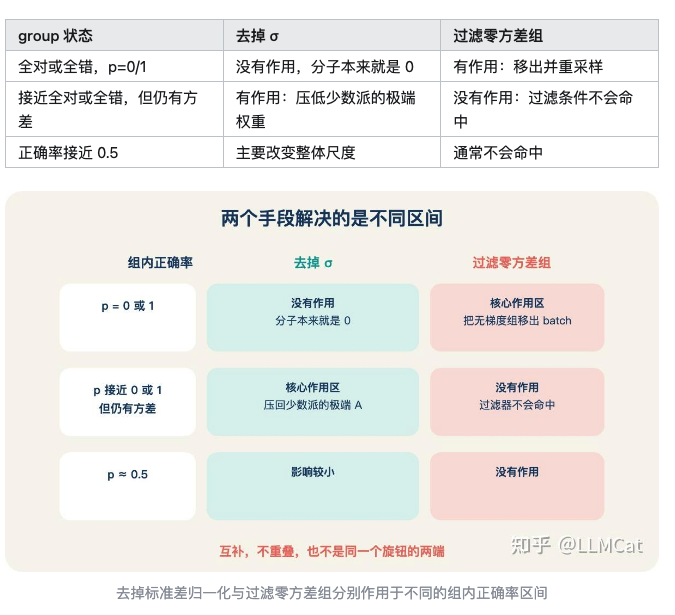

In [15]:
Image(filename='./Image/diff.png')

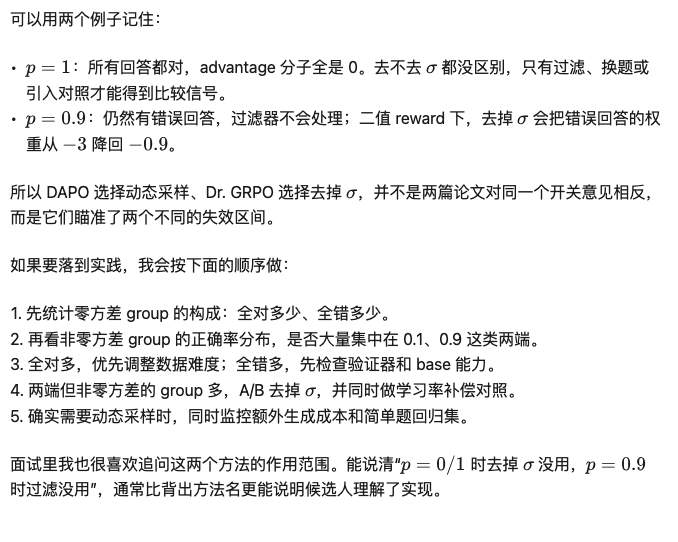

In [16]:
Image(filename='./Image/diff1.png')

## 脱敏实验记录
最后再放我自己的实验记录，因为它只能补充背景，不能用来证明前面的机制。

我有一次观察到明显的坍塌。下一轮同时做了三项修改：刷新参考策略、减小 KL 系数、把训练题型混得更杂。第二轮没有再次出现同样的坍塌。

这个结果只能说明：换了一整套配方以后，现象消失了。 它不能说明三项里的哪一项有效，更不能证明三项都有效，因为我没有做单变量消融。

如果一定要提出假设，我更怀疑题型混合度起了主要作用：题型更杂以后，可能有更多 group 能产生 reward 方差，有效信号不再只集中在少数题型上。但这仍然只是机制推测。

刷新参考策略和减小 KL 都会放松对策略漂移的限制，从直觉上甚至未必有利于保留多样性。因此不能因为第二轮没塌，就把这两项写成“抗坍塌配方”。如果要验证原因，仍然需要分别 A/B。

## 总结
策略坍塌不只是“熵变低”，而是训练把概率越来越集中到少数路径，同时丢掉了原本存在的其他解法。要修它，先要判断是哪一环让比较信号失真。

这篇重点讨论的 $\sigma$归一化，会把每个 prompt 的 reward 分差重新缩放。接近全对或全错时，少数派离均值最远，因此拿到最大的单样本权重。这个权重并不是无限的；使用无偏标准差、G = 16时，上界是 3.75，而且该上限同样适用于连续 reward。

连续 reward 的额外风险在于，标准化会抹掉原始分差的绝对大小。一点微弱的打分器噪声，或者多个 reward 分项中并不重要的细小差别，也可能被扩展成正常强度的 advantage。因此不能只监控标准化后的数值，还要同时看原始 reward range、 $\sigma$ 和各分项。

去掉 $\sigma$的本质是保留原始 reward 分差：分差小的 group 就少更新，分差大的 group 就多更新。它能压低难度两端 group 的极端权重，但通常也会降低总体更新幅度。因此做 A/B 时，需要把“权重结构变了”和“整体步子变小了”尽量分开观察。

过滤零方差 group 解决的是另一件事：全对或全错时根本没有比较信号。它能提高有效 batch 的比例，却会增加生成开销、重新加权 prompt 分布，并让有效题池的收缩更难被看见。

最终不是在“去掉 $\sigma$”和“动态采样”之间二选一，而是先看 group 落在哪个区间：严格零方差、接近零方差但仍有少数派，还是正常的中间难度。不同区间对应不同修法，也对应不同代价。

下一篇深入讲解对称的 clip 区间，分析它为什么实际并不对称，以及为什么“熵在下降”本身不能作为调整 clip 的依据。

# GRPO CLIP边界如何调整？

- https://zhuanlan.zhihu.com/p/2079296721482412050
